In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import logging
import sys
import os

project_root = os.path.dirname(os.getcwd())
sys.path.append(project_root)

from data.config.database import *
from data.utils.date_utils import *
from data.utils.preprocessing import *
from research.metrics import *
import seaborn as sns
import alphalens as al

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 配置日志
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

交易日历缓存已加载，共 13162 条记录


In [2]:
date_str = ','.join(f"'{date}'" for date in get_monthly_last_tradedate(engine,2013,2025))

In [3]:
daily_wide_query="""
select ts_code,trade_date,is_st,is_suspend,circ_mv,total_mv,market,exchange,list_days,l1_code,l1_name,l2_code,l2_name,is_hs300,is_zz500,is_zz800,is_zz1000,is_zz2000
from stock_daily_wide 
where trade_date in ({})
""".format(date_str)

returns_query="""
select * from stock_forward_returns
where trade_date in ({})
""".format(date_str)

factor_query="""
select * from valuation_factor 
where snapshot_date in ({})
""".format(date_str)

In [45]:
# df1=pd.read_sql_query(daily_wide_query,engine)
# df2=pd.read_sql_query(returns_query,engine)
# df3=pd.read_sql_query(factor_query,engine)
# df3 = df3.rename(columns={'snapshot_date':'trade_date'})
# df3 = df3.loc[:,['trade_date','ts_code','bp','rep','sp_q','sp_ttm','gpp_q','gpp_ttm','ep_q','ep_ttm','ocfp_q','ocfp_ttm','divp_ttm',
#                 'rdp_q','rdp_ttm']]

df=pd.merge(df1,df2,on=['ts_code','trade_date'],how='left')
df=pd.merge(df,df3,on=['ts_code','trade_date'],how='left')

In [46]:
df.columns = [str(col) for col in df.columns]
df=df[df.market!='北交所']
df=df[(df.list_days>=365)]
df=df[df.is_st.fillna(0)==0]
df=df[df.is_suspend.fillna(0)==0]
df=df[df.is_next_date_limit_up==0]
df['log_circ_mv']=np.log1p(df['circ_mv'])
df.rename(columns={"trade_date":"date","ts_code":"asset"},inplace=True)
df['date']=pd.to_datetime(df['date'])
df['year']=df['date'].dt.year
df=df.sort_values(by=['asset','date']).reset_index(drop=True)

In [47]:
def category(x):
    if x.is_hs300==1:
        return '1.沪深300'
    elif x.is_zz500==1:
        return '2.中证500'
    elif x.is_zz1000==1:
        return '3.中证1000'
    else:
        return '4.其他'

df['category']=df.apply(category,axis=1)

In [48]:
missing_rates=df.groupby('year').apply(lambda x: x[['bp','rep','sp_q','sp_ttm','gpp_q','gpp_ttm','ep_q','ep_ttm','ocfp_q','ocfp_ttm','rdp_q','rdp_ttm','divp_ttm'
                                                   ]].isnull().mean())

In [49]:
missing_rates.tail(10)

,bp,rep,sp_q,sp_ttm,gpp_q,gpp_ttm,ep_q,ep_ttm,ocfp_q,ocfp_ttm,rdp_q,rdp_ttm,divp_ttm
year,,,,,,,,,,,,,
2016,0.000409,0.000000,0.000409,0.010304,0.000000,0.006312,0.000409,0.010304,0.000409,0.006926,0.999625,0.999625,0.000000
2017,0.000384,0.000000,0.000384,0.004668,0.000000,0.001151,0.000384,0.004668,0.000384,0.002014,0.999616,0.999616,0.000000
2018,0.000192,0.000000,0.000082,0.009557,0.000000,0.006517,0.000082,0.009557,0.000329,0.008434,0.993811,0.999726,0.000000
2019,0.000274,0.000050,0.000050,0.006144,0.000050,0.003109,0.000050,0.006144,0.000348,0.005547,0.335995,0.803109,0.000050
2020,0.000272,0.000049,0.000049,0.007979,0.000049,0.005311,0.000049,0.007979,0.000346,0.007312,0.125463,0.181686,0.000049
2021,0.000159,0.000045,0.000296,0.016211,0.000045,0.013528,0.000227,0.015893,0.000387,0.015415,0.101880,0.142373,0.000045
2022,0.000262,0.000020,0.000545,0.017930,0.000020,0.016518,0.000524,0.017547,0.000565,0.017587,0.083560,0.118150,0.000020
2023,0.000018,0.000000,0.000679,0.013839,0.000000,0.012738,0.000257,0.013362,0.000257,0.013252,0.070793,0.098416,0.000000
2024,0.000000,0.000000,0.000566,0.009721,0.000000,0.008590,0.000212,0.009067,0.000212,0.009067,0.060591,0.083251,0.000000


In [50]:
df['l1_code']=df['l1_code'].fillna('999.其他')

In [51]:
#经典特征标准化
for col in ['bp','rep','sp_q','sp_ttm','gpp_q','gpp_ttm','ep_q','ep_ttm','ocfp_q','ocfp_ttm','divp_ttm']:
    df[col]=df.groupby(['date', 'l1_code'])[col].transform(lambda x: x.fillna(x.mean()))
    df[col]=neutralize_factor(df,col)
    df[col]=rank_factor(df,col)

for col in ['rdp_q','rdp_ttm']:
    df[col]=np.where(df['year']>2019,df.groupby(['date', 'l1_code'])[col].transform(lambda x: x.fillna(x.mean())),df[col])
    df[col]=neutralize_factor(df,col)
    df[col]=rank_factor(df,col)

In [27]:
quick_factor_scan(df[df.year>=2016].set_index(['date','asset']),
                  ['bp','rep','sp_q','sp_ttm','gpp_q','gpp_ttm','ep_q','ep_ttm','ocfp_q','ocfp_ttm','divp_ttm','rdp_q','rdp_ttm'],
                  ['20D'])

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% en

,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,bp,20D,total,0.046171,1.680221,0.658333,0.927273,0.105917,0.874770,0.024196,0.291733
1,rep,20D,total,0.053429,2.365271,0.741667,0.963636,0.086636,0.623258,0.037167,0.438756
2,sp_q,20D,total,0.035944,1.838255,0.708333,0.975758,0.096246,1.278805,0.033744,0.569890
3,sp_ttm,20D,total,0.031493,1.535136,0.650000,0.951515,0.080193,0.962098,0.026186,0.452447
4,gpp_q,20D,total,0.052633,2.647286,0.791667,0.951515,0.129855,1.419137,0.040910,0.525009
5,gpp_ttm,20D,total,0.046571,2.285802,0.766667,0.866667,0.105749,1.121033,0.021768,0.277580
6,ep_q,20D,total,0.049870,1.914449,0.750000,0.939394,0.073977,0.440753,0.032037,0.376063
7,ep_ttm,20D,total,0.039844,1.550627,0.691667,0.878788,0.034515,0.116239,0.013786,0.153303
8,ocfp_q,20D,total,0.026396,2.140767,0.741667,0.903030,0.055037,0.772281,0.032341,0.429430
9,ocfp_ttm,20D,total,0.038880,2.094620,0.725000,0.878788,0.060361,0.590267,0.020692,0.250745


In [37]:
sample=df[df.year>=2016].set_index(['date','asset']).loc[:,['year','category','log_circ_mv','20D']+['bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm','rdp_q']]

In [39]:
# baseline=[]
# baseline_factor=['bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm','rdp_q']
# baseline_best2=evaluate_factor_combinations(sample,baseline_factor,['20D'],combination_size=2).head(5)
# baseline_best3=evaluate_factor_combinations(sample,baseline_factor,['20D'],combination_size=3).head(5)
# baseline_best4=evaluate_factor_combinations(sample,baseline_factor,['20D'],combination_size=4).head(5)
# baseline.append(baseline_best2)
# baseline.append(baseline_best3)
# baseline.append(baseline_best4)
# baseline=pd.concat(baseline)
# baseline.to_csv('baseline.csv',index=False)

In [52]:
#衍生稳定性、时序zscore
for col in ['bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm','rdp_q']:
    for n in [12,24,36]:
        mean=df.groupby('asset')[col].rolling(n,min_periods=n//2).mean().reset_index(drop=True)
        std=df.groupby('asset')[col].rolling(n,min_periods=n//2).std().reset_index(drop=True)
        df[f'{col}_msr_{n}']=mean.div(std,np.nan)
        df[f'{col}_zs_{n}']=(df[col]-mean).div(std,np.nan)

In [53]:
#衍生动量
for n in [3,6,12]:
    df[f'reversal_{n}']=((df['total_mv']-df.groupby('asset')['total_mv'].shift(n))/\
                         df.groupby('asset')['total_mv'].shift(n)).where(df.groupby('asset')['total_mv'].shift(n)>0,np.nan)
    df[f'reversal_{n}'] *= -1

In [54]:
for col in ['bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm','rdp_q']:
    for n in [3,6,12]:
        df[f'{col}_mom_{n}']=((df[col]-df.groupby('asset')[col].shift(n))/abs(df.groupby('asset')[col].shift(n))).where(abs(df.groupby('asset')[col].shift(n))>1e-4,np.nan)
        # df[f'{col}_mom_{n}_clean']=mad_winsorize(df, f'{col}_mom_{n}')
        # df[f'reversal_{n}_clean']=mad_winsorize(df, f'reversal_{n}')
        # df[f'{col}_mom_{n}_pure']=orthogonalize_factor(df, target_factor=f'{col}_mom_{n}_clean', control_factors=[f'reversal_{n}_clean'])
        # df=df.drop(f'{col}_mom_{n}_clean',axis=1)
        # df=df.drop(f'reversal_{n}_clean',axis=1)

In [55]:
#衍生特征标准化
prefixes = ['bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm']
suffixes = ['_msr_12', '_msr_24', '_msr_36', '_zs_12', '_zs_24', '_zs_36', '_mom_3', '_mom_6', '_mom_12']
for prefix in prefixes:
    for suffix in suffixes:
        col=prefix+suffix
        df[col]=df.groupby(['date', 'l1_code'])[col].transform(lambda x: x.fillna(x.mean()))
        df[col]=neutralize_factor(df,col)
        df[col]=rank_factor(df,col)
        print (f'{col} done')

prefixes = ['rdp_q']
suffixes = ['_msr_12', '_msr_24', '_msr_36', '_zs_12', '_zs_24', '_zs_36', '_mom_3', '_mom_6', '_mom_12']
for prefix in prefixes:
    for suffix in suffixes:
        col=prefix+suffix
        df[col]=np.where(df['year']>2019,df.groupby(['date', 'l1_code'])[col].transform(lambda x: x.fillna(x.mean())),df[col])
        df[col]=neutralize_factor(df,col)
        df[col]=rank_factor(df,col)
        print (f'{col} done')

bp_msr_12 done
bp_msr_24 done
bp_msr_36 done
bp_zs_12 done
bp_zs_24 done
bp_zs_36 done
bp_mom_3 done
bp_mom_6 done
bp_mom_12 done
rep_msr_12 done
rep_msr_24 done
rep_msr_36 done
rep_zs_12 done
rep_zs_24 done
rep_zs_36 done
rep_mom_3 done
rep_mom_6 done
rep_mom_12 done
sp_q_msr_12 done
sp_q_msr_24 done
sp_q_msr_36 done
sp_q_zs_12 done
sp_q_zs_24 done
sp_q_zs_36 done
sp_q_mom_3 done
sp_q_mom_6 done
sp_q_mom_12 done
gpp_q_msr_12 done
gpp_q_msr_24 done
gpp_q_msr_36 done
gpp_q_zs_12 done
gpp_q_zs_24 done
gpp_q_zs_36 done
gpp_q_mom_3 done
gpp_q_mom_6 done
gpp_q_mom_12 done
ep_q_msr_12 done
ep_q_msr_24 done
ep_q_msr_36 done
ep_q_zs_12 done
ep_q_zs_24 done
ep_q_zs_36 done
ep_q_mom_3 done
ep_q_mom_6 done
ep_q_mom_12 done
ocfp_ttm_msr_12 done
ocfp_ttm_msr_24 done
ocfp_ttm_msr_36 done
ocfp_ttm_zs_12 done
ocfp_ttm_zs_24 done
ocfp_ttm_zs_36 done
ocfp_ttm_mom_3 done
ocfp_ttm_mom_6 done
ocfp_ttm_mom_12 done
divp_ttm_msr_12 done
divp_ttm_msr_24 done
divp_ttm_msr_36 done
divp_ttm_zs_12 done
divp_ttm_zs

In [56]:
df=df[df.year>=2016].sort_values(['date','asset']).set_index(['date','asset'])

##baseline

In [57]:
# baseline_factor=['bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm','rdp_q']
sample=df.loc[:,['year','category','log_circ_mv','20D']+[col for col in df.columns.tolist() if 
                          col.startswith(('bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm','rdp_q'))]]

In [58]:
# quick_factor_scan(sample,baseline_factor,['20D']).to_csv('original_factors.csv',index=None)
quick_factor_scan(sample,[col for col in df.columns.tolist() if 
                          col.startswith(('bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','divp_ttm','rdp_q'))],['20D'])\
    .to_csv('original_factors_ext.csv',index=None)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% en

In [30]:
baseline=[]
baseline_factor=['bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','rdp_ttm','divp_ttm']
baseline_best2=evaluate_factor_combinations(sample,baseline_factor,['20D'],combination_size=2).head(5)
baseline_best3=evaluate_factor_combinations(sample,baseline_factor,['20D'],combination_size=3).head(5)
baseline_best4=evaluate_factor_combinations(sample,baseline_factor,['20D'],combination_size=4).head(5)
baseline.append(baseline_best2)
baseline.append(baseline_best3)
baseline.append(baseline_best4)
baseline=pd.concat(baseline)
baseline.to_csv('baseline.csv',index=False)

开始评估 8 个因子的 2 组合
总组合数: 28
因子列表: ['bp', 'rep', 'sp_q', 'gpp_q', 'ep_q', 'ocfp_ttm', 'rdp_ttm', 'divp_ttm']
--------------------------------------------------
正在评估组合 1/28: ['bp', 'rep']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
正在评估组合 2/28: ['bp', 'sp_q']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
正在评估组合 3/28: ['bp', 'gpp_q']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
正在评估组合 4/28: ['bp', 'ep_q']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially supp

##研究部分

In [60]:
from itertools import product

In [61]:
all_combinations=[]

for col in ['rdp_q']:
    
    col_ext = [f for f in df.columns.tolist() if f.startswith(col)]
    sample = df.loc[:,['year','category','20D']+col_ext]
    
    original=[col]
    msr=[col+suffix for suffix in ['_msr_12', '_msr_24', '_msr_36']]
    zs=[col+suffix for suffix in ['_zs_12', '_zs_24', '_zs_36']]
    mom=[col+suffix for suffix in ['_mom_3', '_mom_6', '_mom_12']]
    
    best1=[]
    for col in original+msr+zs+mom:
        best1.append(quick_factor_scan(sample, [col],['20D']))
    best1=pd.concat(best1)
    best1=best1.sort_values(by='ic_mean',ascending=False).head(5)
    
    best2=[]
    for combo in list(product(original, msr))+list(product(original, zs))+list(product(original, mom)):
        sample[','.join(combo)]=sample[list(combo)].mean(axis=1)
        best2.append(quick_factor_scan(sample, [','.join(combo)],['20D']))
        sample=sample.drop(','.join(combo),axis=1)
    best2=pd.concat(best2)
    best2=best2.sort_values(by='ic_mean',ascending=False).head(5)
    
    best3=[]
    for combo in list(product(original, msr, zs))+list(product(original, msr, mom))+list(product(original, zs, mom)):
        sample[','.join(combo)]=sample[list(combo)].mean(axis=1)
        best3.append(quick_factor_scan(sample, [','.join(combo)],['20D']))
        sample=sample.drop(','.join(combo),axis=1)
    best3=pd.concat(best3)
    best3=best3.sort_values(by='ic_mean',ascending=False).head(5)
    
    best4=[]
    for combo in list(product(original, msr, zs, mom)):
        sample[','.join(combo)]=sample[list(combo)].mean(axis=1)
        best4.append(quick_factor_scan(sample, [','.join(combo)],['20D']))
        sample=sample.drop(','.join(combo),axis=1)
    best4=pd.concat(best4)
    best4=best4.sort_values(by='ic_mean',ascending=False).head(5)
    
    all_combinations.append(best1)
    all_combinations.append(best2)
    all_combinations.append(best3)
    all_combinations.append(best4)

all_combinations=pd.concat(all_combinations)
all_combinations

Dropped 25.7% entries from factor data: 25.7% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 29.1% entries from factor data: 29.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 31.8% entries from factor data: 31.8% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 34.1% entries from factor data: 34.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 29.1% entries from factor data: 29.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropp

,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,rdp_q_zs_24,20D,total,0.035962,2.291372,0.763158,0.866667,0.103716,1.166379,0.045786,1.108964
0,rdp_q,20D,total,0.035238,2.297800,0.793103,0.781818,0.141697,1.744628,0.102359,1.713132
0,rdp_q_zs_36,20D,total,0.032068,2.322487,0.785714,0.939394,0.088815,0.983897,0.030936,0.797494
0,rdp_q_zs_12,20D,total,0.023063,1.490571,0.646341,0.806061,0.048656,0.358084,0.028190,0.697782
0,rdp_q_msr_12,20D,total,0.018277,1.636226,0.731707,0.672727,0.054904,0.540323,0.046054,1.092449
0,"rdp_q,rdp_q_zs_24",20D,total,0.039529,2.427569,0.793103,0.915152,0.134332,1.659319,0.096327,2.136325
0,"rdp_q,rdp_q_zs_36",20D,total,0.039043,2.487146,0.816092,0.915152,0.134667,1.635778,0.093065,1.954359
0,"rdp_q,rdp_q_mom_3",20D,total,0.036644,2.354589,0.804598,0.781818,0.138234,1.248534,0.106403,1.295231
0,"rdp_q,rdp_q_zs_12",20D,total,0.036596,2.330093,0.770115,0.903030,0.115247,1.408578,0.086220,1.843757
0,"rdp_q,rdp_q_mom_6",20D,total,0.035948,2.248612,0.793103,0.866667,0.119578,1.317375,0.091651,1.374856


In [62]:
all_combinations

,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,rdp_q_zs_24,20D,total,0.035962,2.291372,0.763158,0.866667,0.103716,1.166379,0.045786,1.108964
0,rdp_q,20D,total,0.035238,2.297800,0.793103,0.781818,0.141697,1.744628,0.102359,1.713132
0,rdp_q_zs_36,20D,total,0.032068,2.322487,0.785714,0.939394,0.088815,0.983897,0.030936,0.797494
0,rdp_q_zs_12,20D,total,0.023063,1.490571,0.646341,0.806061,0.048656,0.358084,0.028190,0.697782
0,rdp_q_msr_12,20D,total,0.018277,1.636226,0.731707,0.672727,0.054904,0.540323,0.046054,1.092449
0,"rdp_q,rdp_q_zs_24",20D,total,0.039529,2.427569,0.793103,0.915152,0.134332,1.659319,0.096327,2.136325
0,"rdp_q,rdp_q_zs_36",20D,total,0.039043,2.487146,0.816092,0.915152,0.134667,1.635778,0.093065,1.954359
0,"rdp_q,rdp_q_mom_3",20D,total,0.036644,2.354589,0.804598,0.781818,0.138234,1.248534,0.106403,1.295231
0,"rdp_q,rdp_q_zs_12",20D,total,0.036596,2.330093,0.770115,0.903030,0.115247,1.408578,0.086220,1.843757
0,"rdp_q,rdp_q_mom_6",20D,total,0.035948,2.248612,0.793103,0.866667,0.119578,1.317375,0.091651,1.374856


In [65]:
sample=df.loc[:,['year','category','log_circ_mv','20D']+[col for col in df.columns if col.startswith(('bp','rep','sp_q','gpp_q','ep_q','ocfp_ttm','rdp_q','divp_ttm'))]]

In [66]:
sample['改良bp']=sample[['bp','bp_msr_12','bp_zs_12']].mean(axis=1)
sample['改良rep']=sample[['rep','rep_msr_12','rep_mom_3']].mean(axis=1)
sample['改良sp']=sample[['sp_q','sp_q_zs_12']].mean(axis=1)
sample['改良gpp']=sample[['gpp_q','gpp_q_zs_12']].mean(axis=1)
sample['改良ep']=sample[['ep_q','ep_q_zs_12']].mean(axis=1)

In [67]:
valuation_factors=['改良bp','改良rep','改良sp','改良gpp','改良ep','ocfp_ttm','divp_ttm','rdp_q']

In [69]:
# performance=[]
# best2=evaluate_factor_combinations(sample,valuation_factors,['20D'],combination_size=2).head(5)
# best3=evaluate_factor_combinations(sample,valuation_factors,['20D'],combination_size=3).head(5)
# best4=evaluate_factor_combinations(sample,valuation_factors,['20D'],combination_size=4).head(5)
# performance.append(best2)
# performance.append(best3)
# performance.append(best4)
# performance=pd.concat(performance)
# performance.to_csv('improved.csv',index=False)
performance

,combo_factors,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
8,"改良rep,改良gpp",20D,total,0.072223,3.618944,0.833333,0.987879,0.171664,1.656768,0.065674,1.078325
9,"改良rep,改良ep",20D,total,0.067833,3.132080,0.825000,1.000000,0.154712,1.364729,0.071783,1.121537
2,"改良bp,改良gpp",20D,total,0.067576,2.971679,0.800000,0.987879,0.175784,1.625048,0.061351,1.036799
3,"改良bp,改良ep",20D,total,0.067046,3.040674,0.808333,0.987879,0.169063,1.584912,0.067784,1.071467
7,"改良rep,改良sp",20D,total,0.064489,3.207245,0.816667,1.000000,0.155732,1.509443,0.060318,1.039608
1,"改良bp,改良rep,改良gpp",20D,total,0.072520,3.185736,0.825000,1.000000,0.180334,1.625391,0.066218,1.009343
2,"改良bp,改良rep,改良ep",20D,total,0.072360,3.183608,0.808333,1.000000,0.176556,1.599484,0.068809,1.000320
26,"改良rep,改良gpp,改良ep",20D,total,0.071307,3.423101,0.825000,1.000000,0.174005,1.679737,0.072505,1.195540
11,"改良bp,改良gpp,改良ep",20D,total,0.069971,3.279642,0.825000,1.000000,0.188959,1.806843,0.075622,1.268676
22,"改良rep,改良sp,改良ep",20D,total,0.069289,3.364444,0.833333,1.000000,0.170019,1.604226,0.067404,1.142247


In [71]:
sample['valuation_factor']=sample[['改良rep','改良gpp']].mean(axis=1)

In [74]:
quick_factor_scan(sample,['valuation_factor'],['20D'],group_col='category')

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.1% entries from factor data: 0.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,valuation_factor,20D,1.沪深300,0.032853,0.794786,0.591667,0.806061,0.038857,0.133335,0.012103,0.141589
1,valuation_factor,20D,2.中证500,0.054895,1.769019,0.691667,1.000000,0.108412,0.701500,0.045557,0.604281
2,valuation_factor,20D,3.中证1000,0.074043,2.985452,0.808333,0.987879,0.176920,1.348761,0.068878,0.950998
3,valuation_factor,20D,4.其他,0.083985,4.276425,0.908333,1.000000,0.220395,2.308942,0.098787,1.939706
4,valuation_factor,20D,total,0.072223,3.618944,0.833333,0.987879,0.171664,1.656768,0.065674,1.078325


In [108]:
small=sample[(sample.category.isin(['3.中证1000','4.其他']))&(sample.year>=2016)]

In [109]:
merged_data=al.utils.get_clean_factor(
    factor=small['valuation_factor'],
    forward_returns=small['20D'].to_frame(),
    quantiles=10
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


In [139]:
returns=merged_data.groupby(['date','factor_quantile'])['20D'].mean().unstack()

<Axes: xlabel='date'>

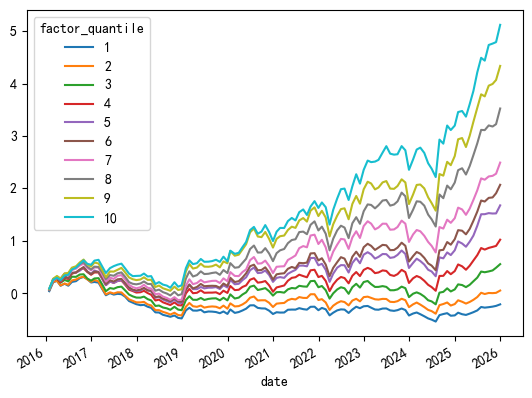

In [140]:
((returns+1).cumprod()-1).plot()

In [141]:
returns['long_short']=returns[10]-returns[1]

<Axes: xlabel='date'>

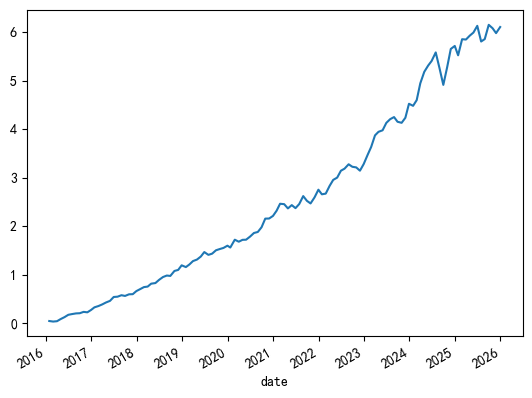

In [143]:
((returns['long_short']+1).cumprod()-1).plot()